### 3

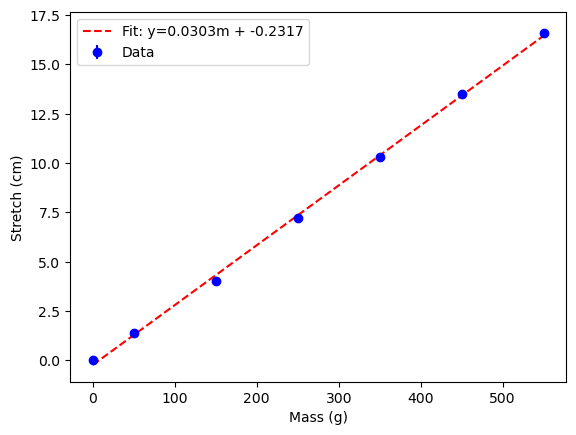

Slope: 0.03035 ± 0.00042
Intercept: -0.23173 ± 0.13562


In [10]:
import numpy as np
import matplotlib.pyplot as plt

m=np.array([0,50,150,250,350,450,550])
x_stretch=np.array([47.5,48.9,51.5,54.7,57.8,61.0,64.1])-47.5

# (a) Best fit with non-zero intercept
fit, cov = np.polyfit(m, x_stretch, 1, cov=True)
slope, intercept = fit
slope_err, intercept_err = np.sqrt(np.diag(cov))

# Plotting
plt.errorbar(m, x_stretch, yerr=0.2, fmt='bo', label='Data')
plt.plot(m, np.polyval(fit, m), 'r--', label=f'Fit: y={slope:.4f}m + {intercept:.4f}')
plt.xlabel('Mass (g)')
plt.ylabel('Stretch (cm)')
plt.legend()
plt.show()

print(f"Slope: {slope:.5f} ± {slope_err:.5f}")
print(f"Intercept: {intercept:.5f} ± {intercept_err:.5f}")

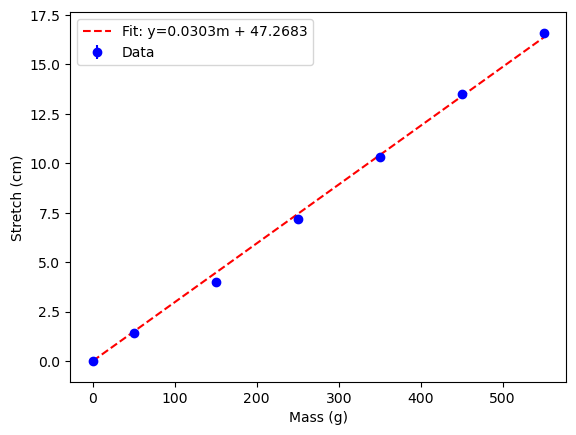

Zero-intercept slope: 0.02976 ± 0.00029


In [9]:
from scipy.optimize import curve_fit
import numpy as np
import matplotlib.pyplot as plt

def linear_zero_intercept(m, a):
    return a * m

m=np.array([0,50,150,250,350,450,550])
x_stretch=np.array([47.5,48.9,51.5,54.7,57.8,61.0,64.1])-47.5

popt, pcov = curve_fit(linear_zero_intercept, m, x_stretch)
slope_zero = popt[0]
slope_zero_err = np.sqrt(pcov[0][0])

m_range=np.linspace(0,550,100)

plt.plot(m_range, linear_zero_intercept(m_range, popt[0]), 'r--', label=f'Fit: y={slope:.4f}m + {intercept:.4f}')
plt.errorbar(m,x_stretch, yerr=0.2, fmt='bo', label='Data')
plt.xlabel('Mass (g)')
plt.ylabel('Stretch (cm)')
plt.legend()
plt.show()

print(f"Zero-intercept slope: {slope_zero:.5f} ± {slope_zero_err:.5f}")

In [39]:
import numpy as np

# Data
m=np.array([0,50,150,250,350,450,550])
x_stretch=np.array([47.5,48.9,51.5,54.7,57.8,61.0,64.1])-47.5
dx = 0.2131  # The quoted uncertainty in cm

# 1. Calculate the best-fit line (non-zero intercept model)
slope, intercept = np.polyfit(m, x_stretch, 1)
x_fit = slope * m + intercept

# 2. Calculate the Chi-Squared value
# Chi^2 = sum( ( (observed - expected) / uncertainty )^2 )
chi_sq = np.sum(((x_stretch - x_fit) / dx)**2)

# 3. Calculate Reduced Chi-Squared
# dof (degrees of freedom) = N points - 2 parameters (slope and intercept)
dof = len(x_stretch) - 2
chi_sq_red = chi_sq / dof

print(f"Reduced Chi-Squared: {chi_sq_red:.4f}")

Reduced Chi-Squared: 0.9999


In [41]:
def linear_zero_intercept(m, a):
    return a * m

m=np.array([0,50,150,250,350,450,550])
x_stretch=np.array([47.5,48.9,51.5,54.7,57.8,61.0,64.1])-47.5

g=9.81

popt, pcov = curve_fit(linear_zero_intercept, m, x_stretch)
slope_zero = popt[0]
slope_zero_err = np.sqrt(pcov[0][0])


k=g/slope_zero/10 # divide by 1/10 to convert to N/m
dk=k*slope_zero_err/slope_zero

print(f"k-constant: {k:.2f} +- {dk:.2f} ")


k-constant: 32.96 +- 0.32 


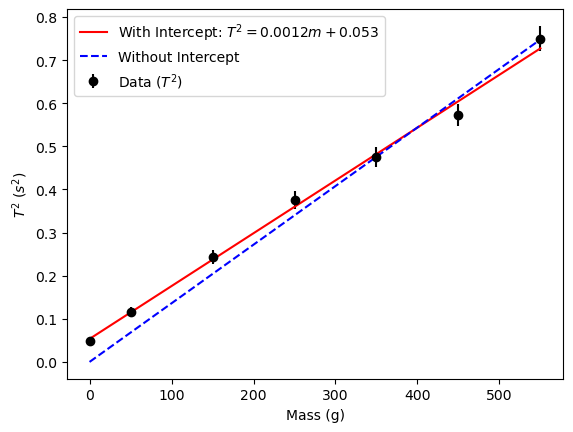

k = 32.21 +/- 1.01 N/m
Reduced Chi-Squared: 0.6439


In [42]:
import numpy as np
import matplotlib.pyplot as plt


m = np.array([0.0,50.0, 150.0, 250.0, 350.0, 450.0, 550.0]) # g
T = np.array([0.221,0.340,0.493,0.612,0.689,0.757,0.866]) # s
dT = 0.017 # s

# Linearize: y = T^2
y = T**2
# Error propagation for T^2: dy = 2 * T * dT
dy = 2 * T * dT

# 2. Part (b): Fits
# Fit with intercept
fit_a, cov_a = np.polyfit(m, y, 1, cov=True)
slope_a, intercept_a = fit_a
err_a = np.sqrt(np.diag(cov_a))

# Fit without intercept (forcing through zero: y = slope * m)
slope_b = np.sum(m * y) / np.sum(m**2)

# 3. Part (c): Uncertainty check (Reduced Chi-Squared)
y_fit = slope_a * m + intercept_a
chi2_red = np.sum(((y - y_fit) / dy)**2) / (len(m) - 2)

# 4. Part (d): Determine k (using intercept-allowed fit for accuracy)
# slope = 4*pi^2 / k  => k = 4*pi^2 / slope
# Note: convert m to kg by dividing slope by 1000
slope_si = slope_a * 1000 
k = (4 * np.pi**2) / slope_si
dk = k * (err_a[0] / slope_a) # Propagation

# Plotting
plt.errorbar(m, y, yerr=dy, fmt='ko', label='Data ($T^2$)')
plt.plot(m, y_fit, 'r-', label=f'With Intercept: $T^2 = {slope_a:.4f}m + {intercept_a:.3f}$')
plt.plot(m, slope_b * m, 'b--', label='Without Intercept')
plt.xlabel('Mass (g)')
plt.ylabel('$T^2$ ($s^2$)')
plt.legend()
plt.show()

print(f"k = {k:.2f} +/- {dk:.2f} N/m")
print(f"Reduced Chi-Squared: {chi2_red:.4f}")

The uncertainty in time used is actually an OVERESTIMATE based on the Reduced Chi^2 being less than 1. 